# AML - Remote Sensing - Practical Work 1

## Introduction
This is the first of a series of 4 practicals work about Remote Sensing. 

The goal is to get familiar with the basic concepts and tools that are used to process and analyze remote sensing data.  

Google Earth Engine (GEE) and its Python API, combined with `geemap` for visualization are classic tools for this purpose and that is the reason why this practical work is based on them.

### Learning objectives
- Be able to launch a GEE project
- Get familiar with the notion of collections
- Learn how to filter and process directly on the server side
- Learn how to bands work and how to compute indices
- Learn how to visualize and export data


This practical work can be done in a Jupyter Notebook or in Google Colab. 

## Step 0. Setup
Earth Engine uses a client-server architecture. Your local code only builds an execution graph that Google processes remotely alongside its data, returning only final results like charts, statistics, or thumbnails.

Core Implications
- Lazy Execution: Creating an ee.Image or ee.FeatureCollection defines a calculation on Google's cloud rather than fetching raw data locally.
- Functional Syntax: Native Python control structures (if, for loops) cannot evaluate Earth Engine objects. Operations must use server-side methods.
- Project Requirement: All API calls require an initialized Google Cloud project enabled for Earth Engine to handle authentication and resource allocation.

In [ ]:
# make sure the packages are available
# !pip install -q earthengine-api geemap

Todo : authenticate this session (opens a browser flow the first time, then caches a token so you don't have to repeat it every run)

Todo : initialize the API with YOUR Google Cloud project.(https://code.earthengine.google.com/)

In [45]:
# Write your code here


> **Common error:** `ee.Initialize()` failing with a permissions/project error almost always means either (a) Earth Engine hasn't been enabled for that Cloud project yet, or (b) you typed the wrong project ID. Double check at the [Earth Engine code editor](https://code.earthengine.google.com/) which project you registered.

## Step 1 : Collections
A **Collection** is simply an ordered set of similar Earth Engine objects, with server-side methods to filter, sort, and process the whole set at once instead of one item at a time. 

You get a collection the same way, regardless of type: by its **dataset ID**, found in the [Earth Engine Data Catalog](https://developers.google.com/earth-engine/datasets).

There is two type of collections in GEE: ImageCollection and FeatureCollection. 

Todo : fill the following table 

| | `ee.ImageCollection` | `ee.FeatureCollection` |
|---|---|---|
| Contains | |  |
| Example dataset | |
| Typical filters |  |  |
| Typical reduction |  | |


## Step 2 : Feature Collection

Feature collections are similar to image collections, but they contain **vector geometries** instead of rasters. Each feature can have **properties** (metadata) attached, which you can filter on. 

Todo : Get FAO GAUL Level 1 for Spain https://developers.google.com/earth-engine/datasets/catalog/FAO_GAUL_2015_level1 and filter FAO GAUL Level 1 for Galicia

Todo : Extract geometry

In [46]:
# Write your code here

Todo : Display the geometry on a map using geemap, in order to do this you must set the center of the map to Galicia and add the geometry to the map as a layer.

In [ ]:
# Write your code here

## Step 3: Image Collection
Image collections are ordered sets of **images** (rasters). Each image can have **bands** (layers) and **metadata** (properties) attached, which you can filter on.  

Todo : explain what sentinel 2 is 

### Filtering an image collection
Real ImageCollections are huge, Sentinel-2 alone has millions of images worldwide going back to 2015. If you don't filter server-side before pulling anything to your notebook, two things happen: your code becomes extremely slow, and it may simply time out or fail.

Two filters:
- **`.filterBounds(geometry)`** — keep only images that intersect a region (a point, a rectangle, a drawn polygon...).
- **`.filterDate(start, end)`** — keep only images whose acquisition date falls in `[start, end)`.

Todo : Get the Sentinel-2 image collection for Galicia, Spain, for the year 2020. Use the geometry you extracted in Step 2 and filter the collection to only include images from that year. https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR_HARMONIZED

Todo: Compute number of images in the filtered collection. Then display the information (getInfo()) of the first image in the filtered collection and display its bands names.

In [47]:
# Write your code here

### Reduction 
As image collections are huge and therefore difficult to handle, it is often useful to reduce them to a single image. This can be done using the `reduce()` method, which applies a reducer to the collection. 

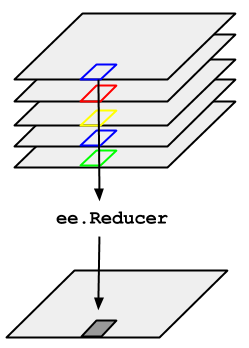
source : https://developers.google.com/earth-engine/guides/reducers_image_collection

Typical reducers include:
- **`.median()`** — compute the median value of each pixel across all images in the collection.
- **`.mean()`** — compute the mean value of each pixel across all images in the collection.
- **`.min()`** — compute the minimum value of each pixel across all images in the collection.
- **`.max()`** — compute the maximum value of each pixel across all images in the collection.

Todo : apply the median reducer to the filtered collection and display the result on a map using geemap.

In [48]:
# Write your code here

### Bands Analysis
The bands are the different layers of information that an image contains. For example, a Sentinel-2 image has 13 bands, each corresponding to a specific wavelength of light.

todo : Visualize the image with visible bands (B4, B3, B2) in RGB

In [49]:
# Write your code here

### Filtering the clouds
Clouds are a common problem in optical remote sensing. They can obscure the land surface and affect the quality of the data. The revisiting interval of Sentinel-2 is 5 days, which means that you can find the same area in the same season with different cloud cover. Therefore, it is important to filter the images by cloud cover before processing them.

Use metadata to filter the images by cloud cover : https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR_HARMONIZED?hl=fr#image-properties


Todo : Filter the cloud cover of the images in the collection to be less than 20% and display the result on a map using geemap.

In [50]:
# Write your code here

## Step 4: Spectral indices
A spectral index is a simple arithmetic combination of bands designed to highlight one physical property, exploiting the fact that different surfaces reflect light differently across wavelengths.
https://www.earthdata.nasa.gov/topics/land-surface/normalized-difference-vegetation-index-ndvi

### NDVI — vegetation health
$$NDVI = \frac{NIR - RED}{NIR + RED}$$

Healthy vegetation reflects strongly in the near-infrared (NIR) and absorbs red light for photosynthesis, so NDVI is high (close to +1) over dense healthy vegetation, near 0 over bare soil, and negative over water.

For Sentinel-2: NIR = `B8`, RED = `B4`.

Todo : write a function that computes the NDVI and add it as a new band to the filtered collection. Then display the result on a map using geemap.


In [51]:
# Write your code here

### NBR — mapping burn severity

Burnt vegetation and ash behave the opposite way from healthy vegetation in the shortwave infrared (SWIR): reflectance rises where the canopy is gone, while NIR reflectance drops. This is exactly what the **Normalized Burn Ratio (NBR)** is built to detect:

$$NBR = \frac{NIR - SWIR2}{NIR + SWIR2}$$

For Sentinel-2: NIR = `B8`, SWIR2 = `B12`.

https://un-spider.org/advisory-support/recommended-practices/recommended-practice-burn-severity/in-detail/normalized-burn-ratio


Todo : write a function that computes the NBR and add it as a new band to the filtered collection. Then display the result on a map using geemap.

In [52]:
# Write your code here


The standard fire-mapping workflow (used operationally by Copernicus EMS and the USGS) compares NBR **before** and **after** a fire:

$$dNBR = NBR_{pre-fire} - NBR_{post-fire}$$

Higher `dNBR` = more severe burning. USGS uses approximate thresholds:

| dNBR range | Severity |
|---|---|
| < 0.10 | Unburned / regrowth |
| 0.10 – 0.27 | Low severity |
| 0.27 – 0.44 | Moderate-low |
| 0.44 – 0.66 | Moderate-high |
| > 0.66 | High severity |


### Case study: Wild fire in Galicia, Spain — July 2022

One of Spain's largest wildfires in decades started on 15-17 July 2022, burning roughly 30,000+ ha.

We'll compute `dNBR` by comparing a **pre-fire** composite (early July) with a **post-fire** composite (late July).


todo : Compute the NBR before the fire (early July) and after the fire (late July) and then compute the dNBR. Then display the result on a map using geemap.

In [53]:
# Write your code here

To validate the results : https://www.arcgis.com/apps/mapviewer/index.html?layers=14154628706f4879b81d0af6328538fb

https://elpais.com/espana/2022-07-18/mapa-de-incendios-activos-en-espana-asi-avanza-el-fuego-del-peor-verano-en-quince-anos.html

## Step 5: download the results
Choose one of the fire zone, clip the dNBR image to this area, and then download it as a GeoTIFF file using the `geemap.ee_export_image()` function. 

In [ ]:
# Write your code here